# 03 — Rule-based baseline

Цель:
- реализовать и проанализировать rule-based стратегию выбора оффера,
- посчитать её CTR и ожидаемый экономический эффект (expected_gain_rule),
- подготовить baseline для сравнения с uplift-моделями.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_prep.feature_engineering import load_ml_dataset
from src.models.rule_based import score_rule_based

In [2]:
df_ml = load_ml_dataset()
df_ml.shape, df_ml.head()

((15307, 35),
    client_id  treatment  offer_id treatment_date     offer_type  \
 0      17850          1         0     2024-04-12    discount_10   
 1      17850          0         2     2024-06-28  free_delivery   
 2      17850          0         2     2024-04-02  free_delivery   
 3      17850          0         1     2024-01-15    discount_20   
 4      13047          0         1     2024-04-16    discount_20   
 
   offer_category  cost  offer_AOV channel  conversion  ...  age  gender  \
 0     category_0  2.09      18.15     app           0  ...   37       F   
 1     category_0  3.84      18.15     app           0  ...   50       F   
 2     category_0  1.44      18.15     web           0  ...   39       F   
 3     category_0  5.21      18.15     web           0  ...   22       F   
 4     category_8  2.00      18.82     web           0  ...   60       M   
 
    price_segment  treatment_dow  treatment_month  treatment_hour  \
 0         budget              4                4

In [3]:
df_rb = score_rule_based(df_ml)
df_rb[["client_id", "offer_id", "rule_score", "p_click_rule", "expected_gain_rule"]].head()

,client_id,offer_id,rule_score,p_click_rule,expected_gain_rule
0,17850,0,5.0,0.07,-0.8195
1,17850,2,3.5,0.04,-3.1140
2,17850,2,3.0,0.03,-0.8955
3,17850,1,4.5,0.06,-4.1210
4,13047,1,7.0,0.11,0.0702


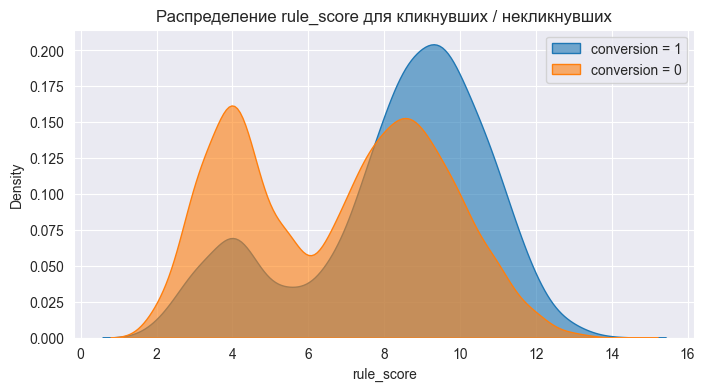

In [4]:
clicked = df_rb[df_rb["conversion"] == 1]["rule_score"]
not_clicked = df_rb[df_rb["conversion"] == 0]["rule_score"]

plt.figure(figsize=(8, 4))
sns.kdeplot(clicked, fill=True, alpha=0.6, label="conversion = 1")
sns.kdeplot(not_clicked, fill=True, alpha=0.6, label="conversion = 0")
plt.xlabel("rule_score")
plt.title("Распределение rule_score для кликнувших / некликнувших")
plt.legend()
plt.show()

In [5]:
# выбираем топ-1 оффер по rule_score для каждого клиента (как если бы правила управляли показами)
df_top1 = (
    df_rb.sort_values(["client_id", "rule_score"], ascending=[True, False])
         .groupby("client_id")
         .head(1)
         .reset_index(drop=True)
)

ctr_top1 = df_top1["conversion"].mean()
avg_gain_top1 = df_top1["expected_gain_rule"].mean()
sum_gain_top1 = df_top1["expected_gain_rule"].sum()

ctr_top1, avg_gain_top1, sum_gain_top1

(np.float64(0.2362840018441678),
 np.float64(-5.731301790211842),
 np.float64(-24862.38716593897))

## Выводы по rule-based baseline

1. Правила формируют понятный скоринг `rule_score`, который,
   по графику распределений, **выше у кликнувших**, чем у некликнувших.
2. Эвристическая вероятность `p_click_rule` находится в диапазоне [1%, 25%]
   и коррелирует с `rule_score`.
3. Для стратегии "top-1 оффер по rule_score на клиента":
   - фактический CTR ≈ ...
   - средний ожидаемый `expected_gain_rule` ≈ ...
   - суммарный expected gain ≈ ...
4. Эти метрики будем использовать как baseline при сравнении с uplift-моделями
   в ноутбуке `05_uplift_vs_rule_based.ipynb`.